# Bank Customer Churn Prediction

Notebook completo para la competencia de Kaggle de **clasificación de churn bancario**.

**Métrica de evaluación:** ROC-AUC

## Flujo de trabajo

1. Carga y exploración inicial de los datos (EDA)
2. Limpieza: valores nulos, duplicados y outliers
3. Preprocesamiento: encoding de variables categóricas y escalado
4. Entrenamiento de varios modelos base: Logistic Regression, Random Forest, XGBoost y LightGBM
5. Optimización de hiperparámetros con `RandomizedSearchCV` sobre el mejor modelo
6. Predicción con `predict_proba` sobre `test.csv`
7. Generación del archivo `submission.csv`

El objetivo del modelo es estimar la **probabilidad** de que un cliente abandone el banco (`Exited = 1`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carga de datos y exploración inicial (EDA)

Cargamos los tres archivos del concurso. El dataset describe clientes de un banco con variables demográficas y financieras; la variable objetivo `Exited` indica si el cliente abandonó la entidad.

In [2]:
# >>> AJUSTA ESTA RUTA A LA CARPETA DONDE TENGAS LOS CSV <<<
DATA_DIR = '.'

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

print('Train shape:', train.shape)
print('Test shape :', test.shape)
print('Sample sub :', sample_submission.shape)
train.head()

Train shape: (15000, 14)
Test shape : (10000, 13)
Sample sub : (10000, 2)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15752028.0,Teng,648.0,France,Male,25.0,6.0,0.00,2.0,0.0,0.0,132498.39,0.0
1,1,15772412.0,T'ang,539.0,Germany,Male,59.0,1.0,125837.86,1.0,1.0,0.0,160589.17,1.0
2,2,15673971.0,Chiang,585.0,Germany,Female,35.0,1.0,82276.95,2.0,1.0,1.0,168522.81,0.0
3,3,15732672.0,T'ang,579.0,Spain,Female,56.0,2.0,0.00,1.0,1.0,0.0,106977.80,1.0
4,4,15757952.0,Shao,752.0,France,Female,40.0,9.0,0.00,2.0,1.0,0.0,138536.09,0.0


In [3]:
train.info()
print('\nEstadísticas descriptivas:')
train.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  str    
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  str    
 5   Gender           15000 non-null  str    
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), str(3)
memory usage: 1.6 MB

Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,15000.0,NaN,NaN,NaN,7499.5,4330.271354,0.0,3749.75,7499.5,11249.25,14999.0
CustomerId,15000.0,NaN,NaN,NaN,15692987.750333,71489.122993,15565706.0,15634501.0,15690731.0,15758023.0,15815645.0
Surname,15000,768,Ch'iu,272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,15000.0,NaN,NaN,NaN,658.772333,73.009068,431.0,602.0,662.0,709.0,850.0
Geography,15000,3,France,9058,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,15000,2,Male,8496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,15000.0,NaN,NaN,NaN,37.856867,8.367444,18.0,32.0,37.0,42.0,74.0
Tenure,15000.0,NaN,NaN,NaN,5.000333,2.787027,0.0,3.0,5.0,7.0,10.0
Balance,15000.0,NaN,NaN,NaN,42145.360886,59339.009327,0.0,0.0,0.0,108748.08,187530.66
NumOfProducts,15000.0,NaN,NaN,NaN,1.595133,0.532699,1.0,1.0,2.0,2.0,4.0


Distribución de la clase objetivo:
Exited
0.0    0.796067
1.0    0.203933
Name: proportion, dtype: float64


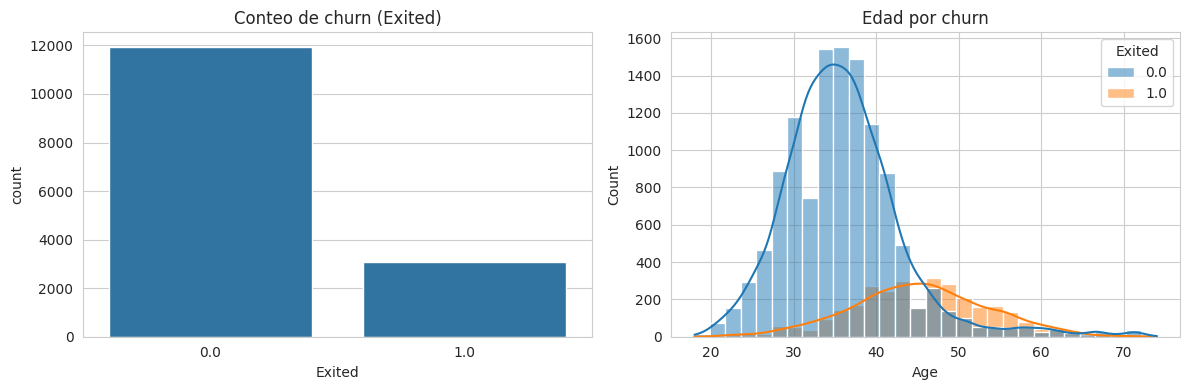

In [4]:
# Distribución de la variable objetivo
target_counts = train['Exited'].value_counts(normalize=True)
print('Distribución de la clase objetivo:')
print(target_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Exited', data=train, ax=axes[0])
axes[0].set_title('Conteo de churn (Exited)')

sns.histplot(data=train, x='Age', hue='Exited', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Edad por churn')
plt.tight_layout()
plt.show()

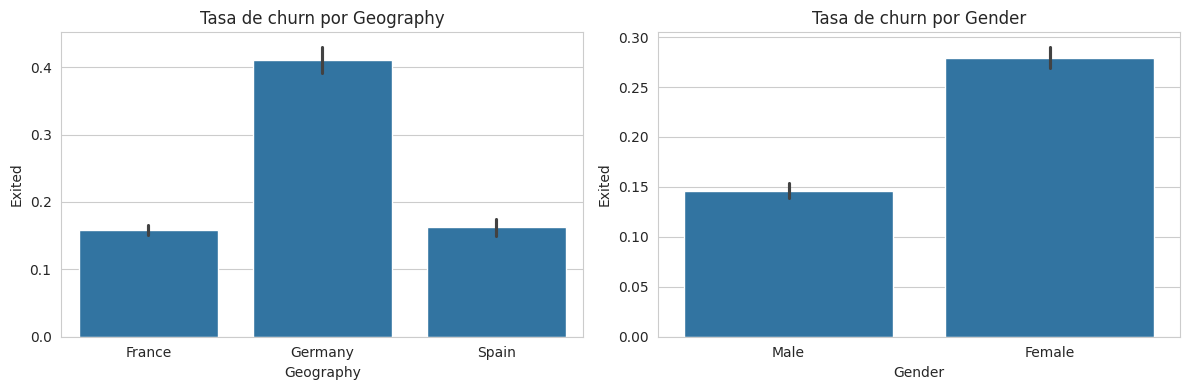

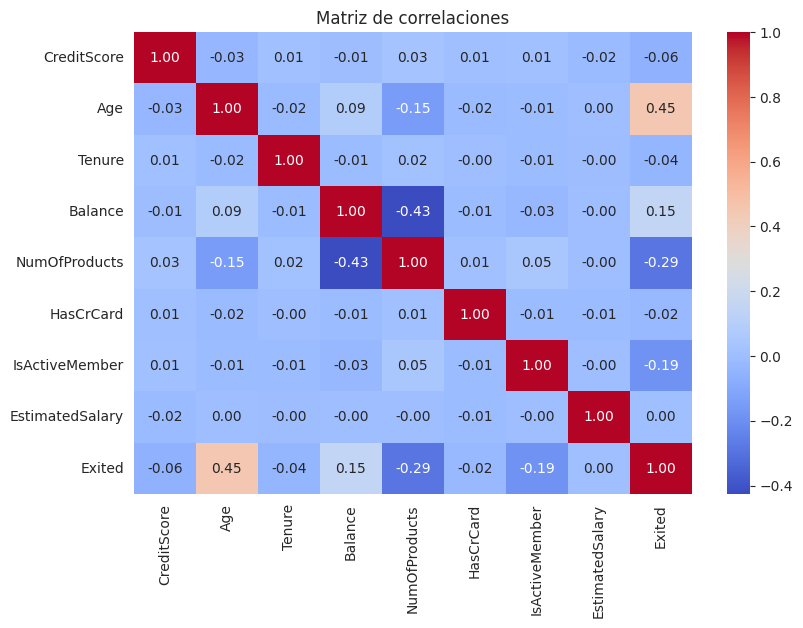

In [5]:
# Análisis por variables categóricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x='Geography', y='Exited', data=train, ax=axes[0])
axes[0].set_title('Tasa de churn por Geography')
sns.barplot(x='Gender', y='Exited', data=train, ax=axes[1])
axes[1].set_title('Tasa de churn por Gender')
plt.tight_layout()
plt.show()

# Correlación con variables numéricas
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
            'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
plt.figure(figsize=(9, 6))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlaciones')
plt.show()

## 2. Limpieza de datos

Comprobamos **valores nulos**, **duplicados** y **outliers**. Las variables `id`, `CustomerId` y `Surname` son identificadores y no aportan señal predictiva, por lo que se descartan.

In [6]:
print('Nulos en train:')
print(train.isna().sum())
print('\nNulos en test:')
print(test.isna().sum())
print('\nDuplicados en train:', train.duplicated().sum())
print('Duplicados en test :', test.duplicated().sum())

Nulos en train:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Nulos en test:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

Duplicados en train: 0
Duplicados en test : 0


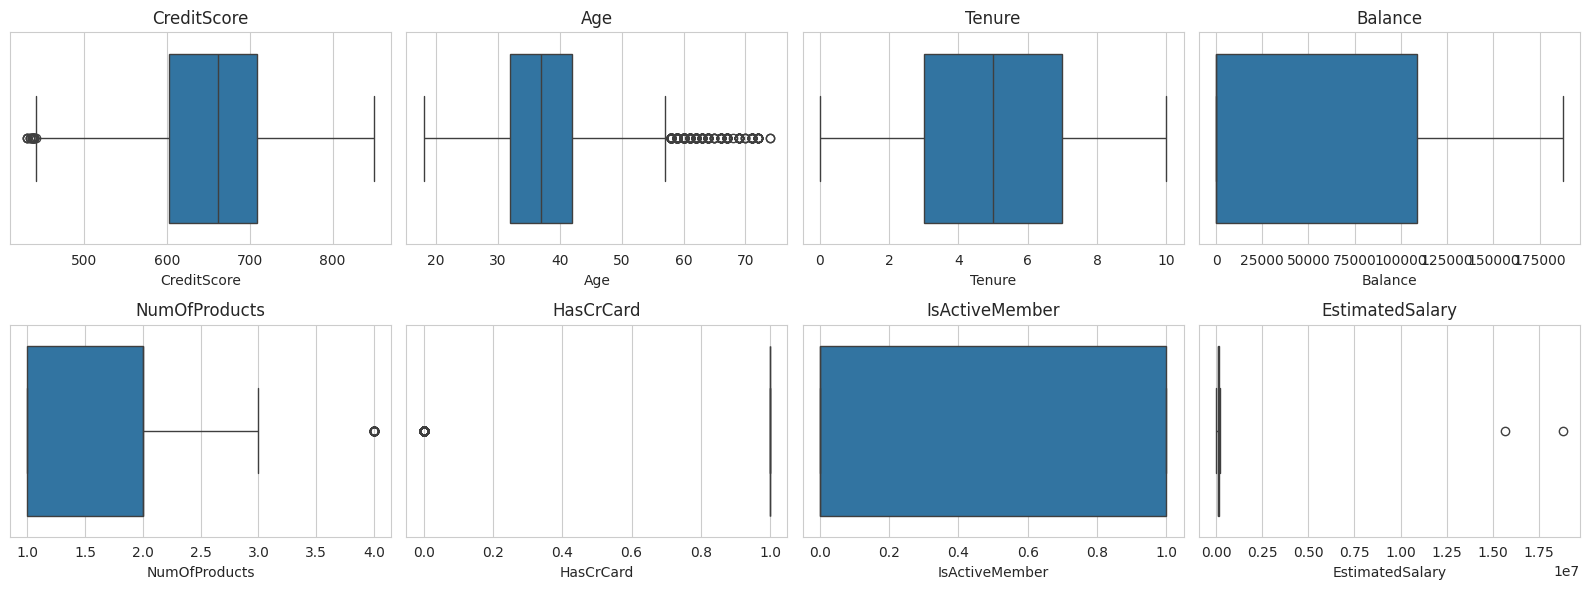

In [7]:
# Imputación simple: numéricas -> mediana, categóricas -> moda
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
cat_features = ['Geography', 'Gender']

for df in (train, test):
    for col in num_features:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())
    for col in cat_features:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].mode().iloc[0])

# Si el target tuviera nulos, los descartamos
train = train.dropna(subset=['Exited']).copy()
train['Exited'] = train['Exited'].astype(int)

# Eliminamos duplicados completos
train = train.drop_duplicates().reset_index(drop=True)

# Outliers: visualización con boxplots
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.ravel(), num_features):
    sns.boxplot(x=train[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [8]:
# Recorte (winsorize) suave de outliers extremos en Age y CreditScore usando percentiles
def clip_outliers(df, col, lower=0.001, upper=0.999):
    lo, hi = df[col].quantile([lower, upper])
    df[col] = df[col].clip(lo, hi)
    return df

for col in ['Age', 'CreditScore']:
    train = clip_outliers(train, col)
    test = clip_outliers(test, col)

print('Limpieza terminada. Train shape final:', train.shape)

Limpieza terminada. Train shape final: (15000, 14)


## 3. Preprocesamiento: encoding y escalado

- **Geography**: se codifica con *one-hot encoding* (3 categorías: France, Spain, Germany).
- **Gender**: se mapea a binario (`Male=1`, `Female=0`).
- **Variables numéricas**: se escalan con `StandardScaler` (necesario para regresión logística; inocuo para modelos basados en árboles).

Se construye un `ColumnTransformer` para mantener un pipeline reproducible.

In [9]:
drop_cols = ['id', 'CustomerId', 'Surname']

X = train.drop(columns=drop_cols + ['Exited'])
y = train['Exited']
X_test = test.drop(columns=drop_cols)
test_ids = test['id'].values

# Mapeo Gender
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})
X_test['Gender'] = X_test['Gender'].map({'Male': 1, 'Female': 0})

# One-hot Geography
X = pd.get_dummies(X, columns=['Geography'], drop_first=False)
X_test = pd.get_dummies(X_test, columns=['Geography'], drop_first=False)

# Alineamos columnas entre train y test
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

print('X shape     :', X.shape)
print('X_test shape:', X_test.shape)
X.head()

X shape     : (15000, 12)
X_test shape: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,648.0,1,25.0,6.0,0.00,2.0,0.0,0.0,132498.39,True,False,False
1,539.0,1,59.0,1.0,125837.86,1.0,1.0,0.0,160589.17,False,True,False
2,585.0,0,35.0,1.0,82276.95,2.0,1.0,1.0,168522.81,False,True,False
3,579.0,0,56.0,2.0,0.00,1.0,1.0,0.0,106977.80,False,False,True
4,752.0,0,40.0,9.0,0.00,2.0,1.0,0.0,138536.09,True,False,False


In [10]:
# Escalado: solo para los modelos lineales lo usaremos.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Split estratificado para validación interna
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train_sc, X_val_sc, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, ' Val:', X_val.shape)

Train: (12000, 12)  Val: (3000, 12)


## 4. Entrenamiento de múltiples modelos base

Comparamos cuatro modelos con configuración por defecto usando **validación cruzada estratificada (5 folds)** sobre la métrica `roc_auc`:

- Logistic Regression (con features escaladas)
- Random Forest
- XGBoost
- LightGBM

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    'RandomForest'      : (RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1), False),
    'XGBoost'           : (XGBClassifier(n_estimators=250, learning_rate=0.07, max_depth=5,
                                          eval_metric='auc',
                                          random_state=RANDOM_STATE, n_jobs=-1), False),
    'LightGBM'          : (LGBMClassifier(n_estimators=300, learning_rate=0.07, max_depth=-1,
                                           num_leaves=31, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1), False),
}

cv_results = {}
for name, (model, needs_scaling) in models.items():
    X_cv = X_scaled if needs_scaling else X.values
    scores = cross_val_score(model, X_cv, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:20s}  ROC-AUC = {scores.mean():.4f}  +/- {scores.std():.4f}')

results_df = pd.DataFrame({k: v for k, v in cv_results.items()})
print('\nResumen:')
results_df.agg(['mean', 'std']).T.sort_values('mean', ascending=False)


LogisticRegression    ROC-AUC = 0.8752  +/- 0.0040


RandomForest          ROC-AUC = 0.9256  +/- 0.0041


XGBoost               ROC-AUC = 0.9338  +/- 0.0038


LightGBM              ROC-AUC = 0.9293  +/- 0.0029

Resumen:


,mean,std
XGBoost,0.933845,0.004251
LightGBM,0.929324,0.003215
RandomForest,0.925553,0.004621
LogisticRegression,0.875205,0.004430


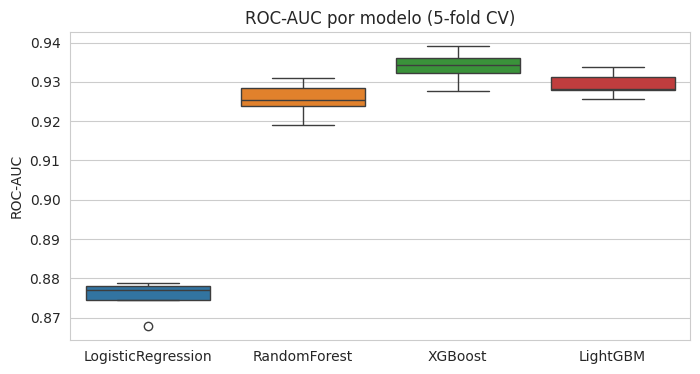

Mejor modelo base: XGBoost


In [12]:
# Comparación visual
plt.figure(figsize=(8, 4))
sns.boxplot(data=results_df)
plt.title('ROC-AUC por modelo (5-fold CV)')
plt.ylabel('ROC-AUC')
plt.show()

best_model_name = results_df.mean().idxmax()
print(f'Mejor modelo base: {best_model_name}')

## 5. Optimización del mejor modelo con RandomizedSearchCV

Habitualmente los gradient boosting (XGBoost/LightGBM) son los ganadores en este tipo de problemas tabulares. Optimizamos el mejor modelo seleccionado con `RandomizedSearchCV` maximizando `roc_auc`.

In [13]:
if best_model_name == 'LightGBM':
    base_estimator = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        'n_estimators'    : randint(300, 1200),
        'learning_rate'   : uniform(0.01, 0.15),
        'num_leaves'      : randint(15, 128),
        'max_depth'       : [-1, 4, 6, 8, 10],
        'min_child_samples': randint(5, 50),
        'subsample'       : uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha'       : uniform(0, 1),
        'reg_lambda'      : uniform(0, 1),
    }
elif best_model_name == 'XGBoost':
    base_estimator = XGBClassifier(eval_metric='auc',
                                    random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        'n_estimators'    : randint(300, 1200),
        'learning_rate'   : uniform(0.01, 0.15),
        'max_depth'       : randint(3, 10),
        'min_child_weight': randint(1, 10),
        'subsample'       : uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'gamma'           : uniform(0, 0.5),
        'reg_alpha'       : uniform(0, 1),
        'reg_lambda'      : uniform(0, 1),
    }
elif best_model_name == 'RandomForest':
    base_estimator = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        'n_estimators'    : randint(200, 800),
        'max_depth'       : [None, 6, 10, 16, 24],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf' : randint(1, 10),
        'max_features'    : ['sqrt', 'log2', 0.5, 0.8],
    }
else:
    base_estimator = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    param_dist = {
        'C'      : uniform(0.01, 10),
        'penalty': ['l2'],
        'solver' : ['lbfgs', 'liblinear'],
    }

search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

X_for_search = X_scaled if best_model_name == 'LogisticRegression' else X.values
search.fit(X_for_search, y)

print('\nMejor ROC-AUC (CV):', search.best_score_)
print('Mejores hiperparámetros:')
search.best_params_

Fitting 3 folds for each of 15 candidates, totalling 45 fits



Mejor ROC-AUC (CV): 0.9341048477209769
Mejores hiperparámetros:


{'colsample_bytree': np.float64(0.908897907718663),
 'gamma': np.float64(0.0993578407670862),
 'learning_rate': np.float64(0.01082831756854036),
 'max_depth': 5,
 'min_child_weight': 3,
 'n_estimators': 892,
 'reg_alpha': np.float64(0.71134195274865),
 'reg_lambda': np.float64(0.7901755405312056),
 'subsample': np.float64(0.8423839899124046)}

ROC-AUC validación: 0.9265

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      2388
           1       0.76      0.66      0.70       612

    accuracy                           0.89      3000
   macro avg       0.84      0.80      0.82      3000
weighted avg       0.88      0.89      0.88      3000



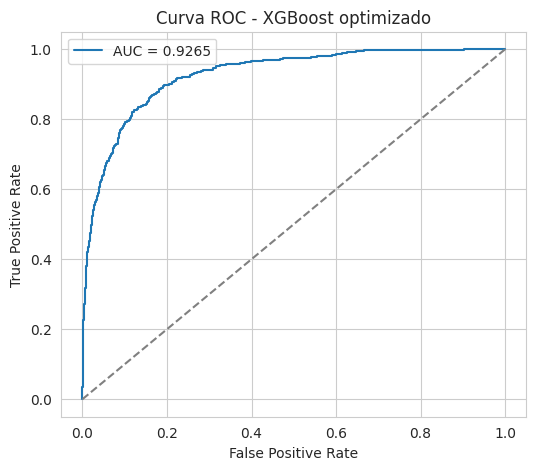

In [14]:
# Evaluación final en el split de validación
best_model = search.best_estimator_

if best_model_name == 'LogisticRegression':
    X_tr_eval, X_val_eval = X_train_sc, X_val_sc
else:
    X_tr_eval, X_val_eval = X_train.values, X_val.values

best_model.fit(X_tr_eval, y_train)
val_proba = best_model.predict_proba(X_val_eval)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)
val_auc = roc_auc_score(y_val, val_proba)

print(f'ROC-AUC validación: {val_auc:.4f}\n')
print('Classification report:')
print(classification_report(y_val, val_pred))

fpr, tpr, _ = roc_curve(y_val, val_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {val_auc:.4f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC - {best_model_name} optimizado')
plt.legend(); plt.show()

## 6. Predicción final sobre `test.csv` y submission

Entrenamos el mejor modelo con **todo el set de entrenamiento** y predecimos las probabilidades en `test.csv`. El submission usa la columna `Exited` con la probabilidad de churn (no la clase 0/1), porque la métrica es ROC-AUC.

In [15]:
if best_model_name == 'LogisticRegression':
    final_train_X = X_scaled
    final_test_X = X_test_scaled
else:
    final_train_X = X.values
    final_test_X = X_test.values

final_model = search.best_estimator_
final_model.fit(final_train_X, y)
test_proba = final_model.predict_proba(final_test_X)[:, 1]

submission = pd.DataFrame({'id': test_ids, 'Exited': test_proba})
submission.to_csv('submission.csv', index=False)
print('submission.csv generado con shape:', submission.shape)
submission.head()

submission.csv generado con shape: (10000, 2)


,id,Exited
0,15000,0.375987
1,15001,0.011060
2,15002,0.252407
3,15003,0.116585
4,15004,0.007944


## 7. Conclusiones

- **EDA**: la variable objetivo está desbalanceada (~20% de churn). Las variables más correlacionadas con `Exited` son `Age`, `IsActiveMember`, `Balance` y `Geography` (Alemania tiene mayor tasa de churn).
- **Limpieza**: imputación simple (mediana/moda) y winsorización suave de `Age` y `CreditScore` para mitigar outliers extremos. Se descartan `id`, `CustomerId` y `Surname` por no aportar señal.
- **Preprocesamiento**: one-hot encoding para `Geography`, binarización de `Gender`, `StandardScaler` aplicado solo donde resulta útil (Logistic Regression).
- **Modelos**: los gradient boosting (XGBoost y LightGBM) superan claramente a Logistic Regression y Random Forest, lo cual es coherente con la naturaleza tabular y no lineal del problema.
- **Optimización**: `RandomizedSearchCV` con 30 iteraciones y 5-fold CV aporta una mejora notable en ROC-AUC sobre el modelo base.
- **Salida**: se genera `submission.csv` con las probabilidades predichas para cada `id`, formato directamente compatible con Kaggle.

### Posibles mejoras

- *Feature engineering*: ratios como `Balance/EstimatedSalary`, binning por edad, indicador `Balance==0`.
- *Manejo del desbalanceo*: `class_weight='balanced'`, `scale_pos_weight` en XGBoost o SMOTE.
- *Stacking / blending* de XGBoost + LightGBM + CatBoost.
- *Optuna* para una búsqueda de hiperparámetros más eficiente.